In [29]:
import os
import sys
import matplotlib.pyplot as plt
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [30]:
from config import config_loader as config_loader
from src.data.preprocessing import load_and_filter_catalog
import numpy as np

In [34]:
def load_rf_config(project_root):
    args = config_loader.load_args_from_yaml(os.path.join(project_root, 'config/Classifier.yaml'))

    Mag_elaps = [6, 6.5, 7, 7.5]
    feature_cols = [
        'Num', 'Mag_max', 'Mag_mean', 'beta', 'b_lsq', 'a_lsq',
        'b_std_lsq', 'std_gr_lsq', 'b_mlk', 'a_mlk', 'b_std_mlk', 'std_gr_mlk',
        'dM_lsq', 'dM_mlk', 'Energy_sqrt', 'prob_x7_lsq', 'prob_x7_mlk',
        'zvalue'
    ] + [f"T_elaps{Mag}" for Mag in Mag_elaps]

    args.Mag_elaps = Mag_elaps
    args.feature_cols = list(set(feature_cols))
    args.dMag = 0.1

    return args

In [35]:
args = load_rf_config(project_root)

In [17]:
base_dir = os.path.join(project_root,  f"data/{args.dataset}")
df = load_and_filter_catalog(base_dir, Mc=args.Mc)

['Chuandian2021.csv']


In [18]:
import src.features.seismic_features as sf
features_df, num_mag = sf.calculate_seismic_features(
    df.to_numpy(), 
    Mc=args.Mc, 
    Mf=args.Mf, 
    Twindow=args.Twindow, 
    Tfore=args.Tfore, 
    dt=args.dt, 
    dMag=args.dMag, 
    Mag_elaps=args.Mag_elaps, 
    L_max=60,
    context_len=args.context_len,
)

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
feature = scaler.fit_transform(features_df[args.feature_cols])
y = np.full(len(features_df), np.nan)
y[features_df['shock_len'].values > 0] = 1
y[features_df['Negative'].values == 1] = 0
valid_mask = (y == 0) | (y == 1)
y = y[valid_mask]
feature = feature[valid_mask]
print(f"正样本数量: {np.sum(y == 1)}")
print(f"负样本数量: {np.sum(y == 0)}")

正样本数量: 1037
负样本数量: 482


In [20]:
from src.data.data_utils import get_split_indices
train_idx, val_idx, test_idx = get_split_indices(len(y), train_ratio=0.8, val_ratio=0.1, seed=0, by_time=args.split_by_time)

In [21]:
f_train = feature[train_idx]
f_val = feature[val_idx]
f_test = feature[test_idx]
y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

In [22]:
def print_sample_distribution(y, dataset_name):
    positive_samples = np.sum(y == 1)
    negative_samples = np.sum(y == 0)
    total_samples = len(y)
    positive_ratio = positive_samples / total_samples
    negative_ratio = negative_samples / total_samples

    print(f"Positive samples: {positive_samples}, Negative samples: {negative_samples}")
    print(f"Total samples: {total_samples}, Positive ratio: {positive_ratio:.2f}, Negative ratio: {negative_ratio:.2f}")
    print()

# 打印每个数据集的样本分布
print_sample_distribution(y_train, "训练集")
print_sample_distribution(y_val, "验证集")
print_sample_distribution(y_test, "测试集")


Positive samples: 822, Negative samples: 393
Total samples: 1215, Positive ratio: 0.68, Negative ratio: 0.32

Positive samples: 104, Negative samples: 47
Total samples: 151, Positive ratio: 0.69, Negative ratio: 0.31

Positive samples: 111, Negative samples: 42
Total samples: 153, Positive ratio: 0.73, Negative ratio: 0.27



In [23]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(f_train, y_train)
y_prob = rf.predict_proba(f_test)[:, 1]  # 取正类的概率

In [24]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

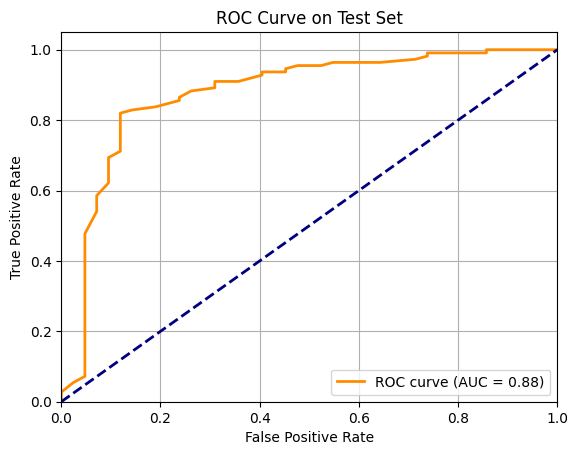

In [25]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # 参考线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


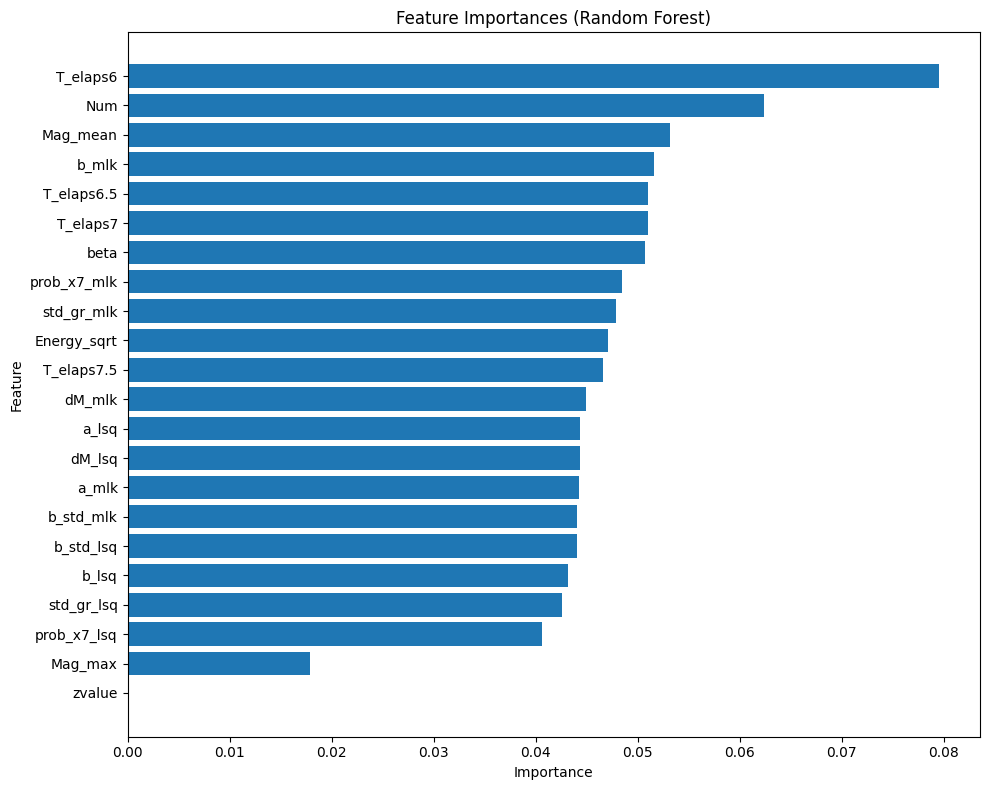

In [26]:
importances = rf.feature_importances_
feature_names = args.feature_cols

indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_importances)), sorted_importances, align="center")
plt.yticks(range(len(sorted_importances)), sorted_names)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.gca().invert_yaxis()  
plt.show()